# 1. Language detection — your Colab model, evaluated locally

**We reuse your trained model; Run All does not retrain it.** Your original notebook is preserved in `reference/Language_Detection_colab_original.ipynb`. The original model is copied byte-for-byte into `models/language/pipeline.joblib`.

Your approach satisfies the traditional-NLP requirement: character TF-IDF plus Logistic Regression. It detects one of 20 languages; it does not translate text or generate an answer.

Your original notebook reports **99.43% validation accuracy**, but did not evaluate its test split. This notebook verifies that result, audits overlap, evaluates the held-out test set, and adds a conservative uncertainty policy without altering model weights.

Sources: [dataset](https://huggingface.co/datasets/papluca/language-identification), [TF-IDF documentation](https://scikit-learn.org/stable/modules/feature_extraction.html), [model persistence compatibility](https://scikit-learn.org/stable/model_persistence.html).


In [1]:
from pathlib import Path
import sys, os, json, warnings, hashlib
from datetime import datetime, timezone
from importlib.metadata import version
ROOT = Path.cwd() if (Path.cwd() / 'src').exists() else Path.cwd().parent
assert (ROOT / 'src/language_detection.py').exists(), 'Open this notebook in ITI ChatBot.'
assert Path(sys.prefix).resolve() == (ROOT / '.venv').resolve(), 'Select the project .venv kernel.'
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
os.environ['MPLCONFIGDIR'] = str(ROOT / '.cache/matplotlib')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.exceptions import InconsistentVersionWarning
from src.language_detection import normalize_text, LANGUAGES
from scripts.download_language_data import download
REPORT, MODEL = ROOT / 'reports/language', ROOT / 'models/language'
provenance = json.loads((REPORT / 'import_provenance.json').read_text())
assert version('scikit-learn') == provenance['training_sklearn_version']
assert hashlib.sha256((MODEL / 'pipeline.joblib').read_bytes()).hexdigest() == provenance['model_sha256']
with warnings.catch_warnings():
    warnings.simplefilter('error', InconsistentVersionWarning)
    pipeline = joblib.load(MODEL / 'pipeline.joblib')
print('Loaded your unchanged model with scikit-learn', version('scikit-learn'))
print('Classes:', list(pipeline.classes_))
print('Number of learned features:', len(pipeline.named_steps['tfidf'].vocabulary_))
print('Training solver iterations:', pipeline.named_steps['clf'].n_iter_)


Loaded your unchanged model with scikit-learn 1.6.1
Classes: ['ar', 'bg', 'de', 'el', 'en', 'es', 'fr', 'hi', 'it', 'ja', 'nl', 'pl', 'pt', 'ru', 'sw', 'th', 'tr', 'ur', 'vi', 'zh']
Number of learned features: 50000
Training solver iterations: [39]


## What your model learned in Colab

Your original training pipeline was:

```python
Pipeline([
    ('tfidf', TfidfVectorizer(analyzer='char', ngram_range=(2, 4),
                            max_features=50000, sublinear_tf=True)),
    ('clf', LogisticRegression(max_iter=1000, C=1.0, solver='lbfgs', n_jobs=-1))
])
```

It was fitted on training text and labels only. The fitted vectorizer and classifier were exported together.

- **Character n-grams:** overlapping sequences of 2, 3, and 4 characters. `hello` has `hel`, `ell`, and `llo` as its 3-grams. These features capture language patterns without word dictionaries.
- **TF-IDF:** weights feature occurrence while down-weighting features common across training documents. Sublinear TF applies `1 + log(count)` to reduce the influence of repetition.
- **50,000 features:** limits vocabulary size and memory use.
- **Logistic Regression:** learns weighted evidence for each language. `C=1.0` controls regularization; smaller C means stronger regularization. `max_iter=1000` is an upper limit, not the actual number of iterations.
- **Preprocessing:** the saved vectorizer lowercases by default. It retains scripts and accents; we preserve its exact processing at prediction time. The normalization function used in the duplicate audit below does not replace the model's preprocessing.

This is one trained approach. Character features are a reasonable enhancement, but your notebook contains no baseline comparison, so we do not claim measured improvement over a word-based model. No GPU is needed for this model.


## Load the supplied splits

The original training used 70,000 rows, with 10,000 validation and 10,000 test rows. We cache the evaluation files from a fixed repository revision and record checksums. The original notebook did not record its training dataset revision or all package versions; we cannot reconstruct that provenance exactly. Matching the recorded scikit-learn version and reproducing validation accuracy are useful compatibility checks.


In [2]:
download()
raw = {split: pd.read_csv(ROOT / f'data/raw/language/{split}.csv') for split in ['train','valid','test']}
for split, frame in raw.items():
    assert set(frame.columns) == {'text','labels'}
    assert not frame[['text','labels']].isna().any().any()
    assert set(frame.labels) == set(LANGUAGES)
    print(split, 'rows:', len(frame))
train, valid, test = [raw[s] for s in ['train','valid','test']]
display(train.head())
display(pd.DataFrame({s: frame.labels.value_counts() for s, frame in raw.items()}).sort_index())


Dataset files ready; revision and checksums recorded.


train rows: 70000
valid rows: 10000
test rows: 10000


,labels,text
0,pt,"os chefes de defesa da estónia, letónia, lituâ..."
1,bg,размерът на хоризонталната мрежа може да бъде ...
2,zh,很好，以前从不去评价，不知道浪费了多少积分，现在知道积分可以换钱，就要好好评价了，后来我就把...
3,th,สำหรับ ของเก่า ที่ จริงจัง ลอง honeychurch ...
4,ru,Он увеличил давление .


,train,valid,test
labels,,,
ar,3500,500,500
bg,3500,500,500
de,3500,500,500
el,3500,500,500
en,3500,500,500
es,3500,500,500
fr,3500,500,500
hi,3500,500,500
it,3500,500,500


## Audit exact duplicates without changing your trained model

Normalize Unicode to NFC, lowercase, and collapse whitespace for the audit. Count repeated texts and label conflicts in each split, and overlaps with earlier splits. The original model has already learned from the training set, so we cannot retroactively remove training duplicates without retraining.

For uncertainty-threshold selection, use unique validation texts absent from training. For an additional test measurement, use unique test texts absent from both training and validation, excluding within-test label conflicts. Also report the score on **all 10,000 original test rows**, so these two measurements are clearly distinguished. This audit does not detect near duplicates.


,split,original_rows,repeated_text_rows,conflicting_label_rows,overlap_with_earlier_splits,unique_unseen_nonconflicting_rows
0,train,70000,1029,11,0,68967
1,valid,10000,1010,0,132,8877
2,test,10000,667,0,188,9171


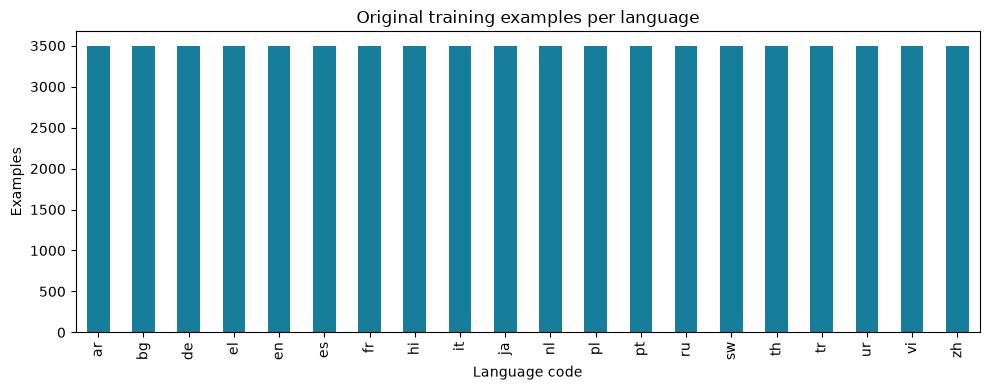

In [3]:
seen, audit, unique_unseen = set(), [], {}
for split in ['train','valid','test']:
    frame = raw[split].copy()
    frame['normalized'] = frame.text.map(normalize_text)
    conflicts = set(frame.groupby('normalized').labels.nunique().loc[lambda counts: counts > 1].index)
    earlier_overlap = frame.normalized.isin(seen)
    selected = frame[~earlier_overlap & ~frame.normalized.isin(conflicts) & frame.normalized.ne('')].drop_duplicates('normalized')
    unique_unseen[split] = selected.index.to_numpy()
    audit.append({'split': split, 'original_rows': len(frame),
                  'repeated_text_rows': int(frame.duplicated('normalized').sum()),
                  'conflicting_label_rows': int(frame.normalized.isin(conflicts).sum()),
                  'overlap_with_earlier_splits': int(earlier_overlap.sum()),
                  'unique_unseen_nonconflicting_rows': len(selected)})
    seen.update(frame.normalized)
audit_df = pd.DataFrame(audit)
audit_df.to_csv(REPORT / 'data_audit.csv', index=False)
display(audit_df)
fig, ax = plt.subplots(figsize=(10,4))
train.labels.value_counts().sort_index().plot.bar(ax=ax,color='#167d9a')
ax.set(title='Original training examples per language',xlabel='Language code',ylabel='Examples')
fig.tight_layout()
fig.savefig(REPORT / 'class_distribution.png',dpi=150)
plt.show()


## Verify validation results and choose uncertainty behavior

The raw classifier always chooses one of 20 labels. Add three safeguards: at least four alphabetic characters, some known vector features, and a confidence threshold. This is a heuristic rejection policy, **not a trained unknown-language detector**. It can reject valid short messages and still accept unsupported languages.

The threshold is selected on unique unseen validation examples, before looking at test results: choose the lowest value in a fixed grid with at least 99% accepted accuracy and 50% coverage. If none qualifies, choose the highest accepted accuracy among thresholds with at least 50% coverage. Coverage is the fraction of messages accepted. Model probabilities are uncalibrated estimates, not guarantees.


In [4]:
vectorizer, classifier = pipeline.named_steps['tfidf'], pipeline.named_steps['clf']
classes = classifier.classes_
val_features = vectorizer.transform(valid.text)
val_probabilities = classifier.predict_proba(val_features)
val_predictions = classes[val_probabilities.argmax(axis=1)]
val_scores = val_probabilities.max(axis=1)
validation_accuracy = float(accuracy_score(valid.labels, val_predictions))
print(f'Locally reproduced validation accuracy: {validation_accuracy:.4%}')
print(f'Original notebook: {provenance["original_validation_accuracy"]:.2%}')
assert round(validation_accuracy, 4) == provenance['original_validation_accuracy'], 'Investigate discrepancy before using this model.'
min_letters = 4
eligible = valid.text.map(lambda text: sum(c.isalpha() for c in normalize_text(text)) >= min_letters).to_numpy(copy=True)
eligible &= np.asarray(val_features.getnnz(axis=1)) > 0
indices = unique_unseen['valid']
assert len(indices) > 0
threshold_rows=[]
for candidate_threshold in [0.0,0.3,0.5,0.6,0.7,0.8,0.9]:
    accepted = eligible[indices] & (val_scores[indices] >= candidate_threshold)
    truth = valid.labels.to_numpy()[indices]
    pred = val_predictions[indices]
    threshold_rows.append({'threshold':candidate_threshold,'coverage':float(accepted.mean()),
                           'accepted_accuracy':float((pred[accepted]==truth[accepted]).mean()) if accepted.any() else None})
threshold_table = pd.DataFrame(threshold_rows)
qualified = threshold_table[(threshold_table.coverage >= 0.5)&(threshold_table.accepted_accuracy >= 0.99)]
if len(qualified):
    threshold=float(qualified.sort_values('threshold').iloc[0].threshold)
else:
    threshold=float(threshold_table[threshold_table.coverage >= 0.5].sort_values(['accepted_accuracy','coverage'],ascending=False).iloc[0].threshold)
threshold_table.to_csv(REPORT/'validation_thresholds.csv',index=False)
display(threshold_table)
print('Frozen confidence threshold:',threshold)


Locally reproduced validation accuracy: 99.4300%
Original notebook: 99.43%


,threshold,coverage,accepted_accuracy
0,0.0,0.999549,0.994252
1,0.3,0.996508,0.995817
2,0.5,0.985693,0.998514
3,0.6,0.974541,0.998960
4,0.7,0.958094,0.999647
5,0.8,0.928016,0.999757
6,0.9,0.842064,0.999866


Frozen confidence threshold: 0.0


## Final test evaluation

**Accuracy** counts all correct predictions. **Macro-F1** weights each language equally. **Accepted accuracy** includes only predictions passing our guards and must be reported alongside coverage.

The confusion matrix has actual languages on rows and predicted languages on columns. Off-diagonal counts are mistakes. Inspect errors to explain limitations; do not change the threshold based on this test set.

**Observed validation decision:** the selected threshold is 0.0, because the predeclared 99% target is already met without probability filtering. Consequently, the current deployment only rejects insufficient text or missing features; low confidence alone does not cause rejection. A stricter policy would need a deliberate validation decision and independent confirmation, especially on short support messages.


{
  "model": "user_colab_character_tfidf_logistic_regression",
  "validation_accuracy": 0.9943,
  "confidence_threshold": 0.0,
  "min_letters": 4,
  "original_test": {
    "examples": 10000,
    "accuracy": 0.9939,
    "macro_f1": 0.9939183822941692,
    "accepted_examples": 10000,
    "coverage": 1.0,
    "accepted_accuracy": 0.9939
  },
  "unique_unseen_test": {
    "examples": 9171,
    "accuracy": 0.9938937956602334,
    "macro_f1": 0.9937440245407346,
    "accepted_examples": 9171,
    "coverage": 1.0,
    "accepted_accuracy": 0.9938937956602334
  }
}


,precision,recall,f1-score,support
ar,1.000000,0.9980,0.998999,500.0000
bg,0.998004,1.0000,0.999001,500.0000
de,1.000000,1.0000,1.000000,500.0000
el,1.000000,1.0000,1.000000,500.0000
en,0.992063,1.0000,0.996016,500.0000
es,0.995992,0.9940,0.994995,500.0000
fr,0.998004,1.0000,0.999001,500.0000
hi,1.000000,0.9680,0.983740,500.0000
it,0.992000,0.9920,0.992000,500.0000
ja,1.000000,1.0000,1.000000,500.0000


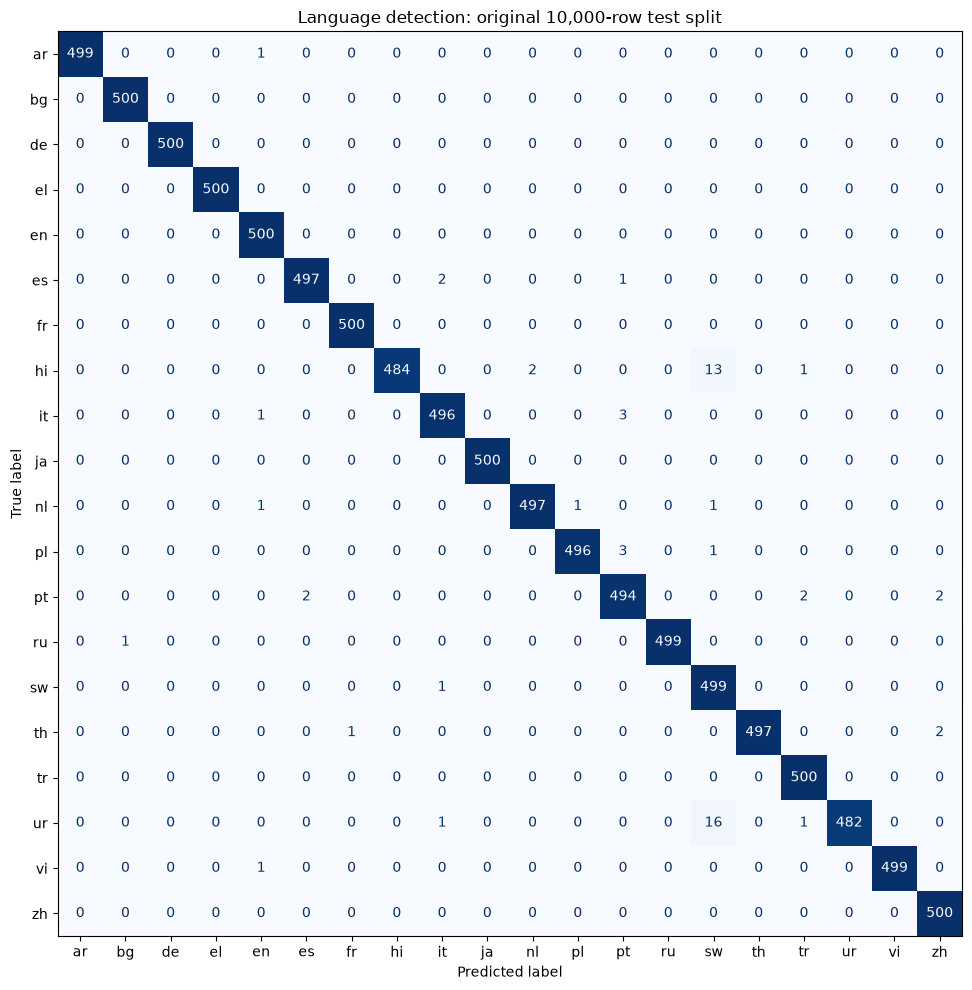

,text,labels,predicted,confidence
127,Ja mam to samo.,pl,pt,0.229178
501,aadhunik mahilaen Romantic shira mein maheen h...,hi,sw,0.624282
718,"Us din mai apna wheel ghooma raha tha, mjhe na...",ur,sw,0.540412
1354,Romney wint Nevada Caucus,nl,pl,0.159783
1675,is nivesh ne 60 gharo ka navikaran aur maamool...,hi,sw,0.469739
1910,To także kwestia gustu.,pl,sw,0.315693
2145,"To mai gaya, mai Washington D.C. gaya aur mai ...",ur,sw,0.327986
2207,"Llego incompleto , le falta una puerta!!",es,it,0.425356
2500,คนที่ L'academie Internationale des Arts et de...,th,fr,0.400323
2842,"gupt karya ke liye, beshak, White House Counte...",hi,sw,0.207525


In [5]:
test_features = vectorizer.transform(test.text)
probabilities = classifier.predict_proba(test_features)
predictions = classes[probabilities.argmax(axis=1)]
scores = probabilities.max(axis=1)
accepted = test.text.map(lambda text: sum(c.isalpha() for c in normalize_text(text)) >= min_letters).to_numpy(copy=True)
accepted &= np.asarray(test_features.getnnz(axis=1)) > 0
accepted &= scores >= threshold

def evaluate(indices):
    truth = test.labels.to_numpy()[indices]
    pred = predictions[indices]
    mask = accepted[indices]
    return {'examples':len(indices),'accuracy':float(accuracy_score(truth,pred)),
            'macro_f1':float(f1_score(truth,pred,average='macro')),
            'accepted_examples':int(mask.sum()),'coverage':float(mask.mean()),
            'accepted_accuracy':float(accuracy_score(truth[mask],pred[mask])) if mask.any() else None}
metrics={'model':'user_colab_character_tfidf_logistic_regression',
         'validation_accuracy':validation_accuracy,'confidence_threshold':threshold,'min_letters':min_letters,
         'original_test':evaluate(np.arange(len(test))),
         'unique_unseen_test':evaluate(unique_unseen['test'])}
(REPORT/'test_metrics.json').write_text(json.dumps(metrics,indent=2)+'\n')
print(json.dumps(metrics,indent=2))
per_class=pd.DataFrame(classification_report(test.labels,predictions,output_dict=True,zero_division=0)).T
per_class.to_csv(REPORT/'classification_report.csv')
display(per_class)
fig,ax=plt.subplots(figsize=(11,10))
ConfusionMatrixDisplay(confusion_matrix(test.labels,predictions,labels=classes),display_labels=classes).plot(ax=ax,cmap='Blues',colorbar=False,values_format='d')
ax.set_title('Language detection: original 10,000-row test split')
fig.tight_layout()
fig.savefig(REPORT/'confusion_matrix.png',dpi=140)
plt.show()
wrong=predictions != test.labels.to_numpy()
errors=test.loc[wrong,['text','labels']].copy()
errors['predicted']=predictions[wrong]
errors['confidence']=scores[wrong]
errors.to_csv(REPORT/'test_errors.csv',index=False)
display(errors.head(12))


## Save metadata for local deployment

The fitted model file stays unchanged. We save its threshold and evaluation separately. The prediction module loads both and can later connect to FastAPI. Only load trusted model files; joblib/pickle can execute code.


In [6]:
metadata={**metrics,'evaluated_at_utc':datetime.now(timezone.utc).isoformat(),
          'provenance':provenance,'evaluation_dataset':json.loads((ROOT/'data/raw/language/manifest.json').read_text()),
          'split_audit':audit,'languages':LANGUAGES,
          'versions':{package:version(package) for package in ['scikit-learn','numpy','pandas','joblib']},
          'limitations':['Original training dataset revision and full environment were not recorded.',
                         'Exact overlap audit does not detect near duplicates.',
                         'Unknown-language handling is heuristic; unsupported languages can be confidently misclassified.',
                         'Short messages, mixed languages, dialects, and Arabizi require separate evaluation.',
                         'Test accuracy is not a guarantee of customer-support accuracy.']}
(MODEL/'metadata.json').write_text(json.dumps(metadata,indent=2)+'\n')
(REPORT/'evaluation_metadata.json').write_text(json.dumps(metadata,indent=2)+'\n')
assert hashlib.sha256((MODEL/'pipeline.joblib').read_bytes()).hexdigest() == provenance['model_sha256']
print('Model weights unchanged; deployment metadata saved.')


Model weights unchanged; deployment metadata saved.


## Try the saved model without retraining

This cell can run independently after a kernel restart. These hand-written examples are qualitative checks only, not another benchmark. Modify a message to explore behavior. Look carefully at `unknown`: it means the module abstained, not that it identified a particular unsupported language.


In [7]:
from pathlib import Path
import sys
ROOT = Path.cwd() if (Path.cwd() / 'src').exists() else Path.cwd().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from src.language_detection import LanguageDetector
import pandas as pd

detector = LanguageDetector()
examples = [
    ('Where is my order? I have been waiting for a week.', 'English'),
    ('أريد معرفة موعد وصول طلبي', 'Arabic'),
    ('عايزة أعرف الأوردر بتاعي هيوصل امتى', 'Egyptian Arabic — qualitative only'),
    ('Je voudrais savoir où se trouve ma commande.', 'French'),
    ('¿Dónde está mi pedido?', 'Spanish'),
    ('Wo ist meine Bestellung?', 'German'),
    ('我的订单什么时候到？', 'Chinese'),
    ('注文はいつ届きますか？', 'Japanese'),
    ('OK', 'Ambiguous short input'),
    ('12345', 'No language evidence'),
    ('', 'Empty input'),
    ('عايزة track my order', 'Mixed language — no single gold label'),
    ('ana 3ayza el order', 'Arabizi — outside validated coverage'),
]
qualitative = pd.DataFrame([{'message': text, 'description': description, **detector.predict(text)} for text, description in examples])
display(qualitative)
qualitative.to_csv(ROOT / 'reports/language/qualitative_examples.csv', index=False)
assert detector.predict('')['language'] == 'unknown'
assert detector.predict('12345')['language'] == 'unknown'
assert detector.predict('OK')['language'] == 'unknown'
print('Saved model and basic uncertainty checks passed.')


,message,description,language,language_name,candidate,confidence,reason
0,Where is my order? I have been waiting for a w...,English,en,English,en,0.7841,accepted
1,أريد معرفة موعد وصول طلبي,Arabic,ar,Arabic,ar,0.6739,accepted
2,عايزة أعرف الأوردر بتاعي هيوصل امتى,Egyptian Arabic — qualitative only,ar,Arabic,ar,0.8768,accepted
3,Je voudrais savoir où se trouve ma commande.,French,fr,French,fr,0.7559,accepted
4,¿Dónde está mi pedido?,Spanish,es,Spanish,es,0.3038,accepted
5,Wo ist meine Bestellung?,German,de,German,de,0.7449,accepted
6,我的订单什么时候到？,Chinese,zh,Chinese,zh,0.7928,accepted
7,注文はいつ届きますか？,Japanese,ja,Japanese,ja,0.3778,accepted
8,OK,Ambiguous short input,unknown,Uncertain,NaN,NaN,too_short_or_no_letters
9,12345,No language evidence,unknown,Uncertain,NaN,NaN,too_short_or_no_letters


Saved model and basic uncertainty checks passed.


## What you should be able to explain

1. Why are character n-grams useful for language detection?
2. How does TF-IDF differ from raw counts?
3. What does the vectorizer learn and what does Logistic Regression learn?
4. Why was the vectorizer fitted on training text only?
5. Why does matching scikit-learn versions matter when loading saved models?
6. How did validation data determine the uncertainty threshold?
7. What is the difference between accuracy, macro-F1, and coverage?
8. Why can an unsupported language receive a confident prediction?
9. Why is the original test score different from the unique unseen subset score?

**Assessment demo:** show validation reproduction, test metrics, a confusion-matrix error, a new prediction, and an uncertain short input. No Colab connection or GPU is needed to run the saved model locally. No measured baseline improvement is claimed because your original notebook trained one model.
